In [1]:
# Import libraries
import sys
import os
import json
import pandas as pd
from pathlib import Path
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Add the src directory to Python path
project_root = Path.cwd().parent.parent  # Go up to bonn_thesis/src/
sys.path.insert(0, str(project_root))

# Set pandas options
pd.set_option('display.max_columns', None)

from bonn_thesis.config import SOEP_DATA_BLD, LINKEDIN_MATCHED_TO_SOEP_BLD


## Load data

Data is loaded from the following files:
* wage_soep_exp_xx_results.jsonl: this file contains LLM labor income estimates using the OpenAI API. Metadata and description is saved to soep_metadata.csv
* soep_agg_part_xx.parquet: these are the individual-level observations used to generate profiles for OpenAI income estimates.
* soep_selected.parquet: these are the SOEP individual-level observations that serve as reference wages.

<br>Income estimates are extracted from the responses and there's a condition that income should be >10.000 euros. This is because the responses are limited to 20 tokens and some responses have extra characters (despite explicitly asking for numbers only). So it can happen that numbers appear not completely.
<br>Income is estimated yearly and converted to monthly income by dividing by 12 months to match the monthly gross labor income in SOEP
<br><br>**Important:** LLM estimates are first merged with individual SOEP observations. Then SOEP reference wages are filtered to only include observations matching the demographics of the LLM-estimated profiles. Finally, both datasets are grouped separately by demographics (syear, isco_3_name, education_grouped, sex_en, state_en) and merged together.

In [2]:
# Define the experiment number you want to load
experiment_num = "14"

# Get all matching files
openai_responses_dir = SOEP_DATA_BLD / "openai_responses"
matching_files = sorted(openai_responses_dir.glob(f"wage_soep_exp_{experiment_num}*.jsonl"))

print(f"Found {len(matching_files)} files for experiment {experiment_num}:")
for file in matching_files:
    print(f"  - {file.name}")

# Load all matching files
openai_data = []
for file_path in matching_files:
    with open(file_path, 'r') as f:
        for line in f:
            openai_data.append(json.loads(line))

print(f"\nTotal responses loaded: {len(openai_data)}")

Found 5 files for experiment 14:
  - wage_soep_exp_14a_results.jsonl
  - wage_soep_exp_14b_results.jsonl
  - wage_soep_exp_14c_results.jsonl
  - wage_soep_exp_14d_results.jsonl
  - wage_soep_exp_14e_results.jsonl

Total responses loaded: 70378


In [3]:
# Load SOEP aggregated data (individual observations for OpenAI)
soep_agg_path = SOEP_DATA_BLD / "aggregated" / "soep_agg_part_14.parquet"
soep_individual_df = pd.read_parquet(soep_agg_path)

# Rename columns to indicate these are individual observations
soep_individual_df = soep_individual_df.rename(columns={
    'pglabgro_mean': 'pglabgro_individual',
    'pgexpft_mean': 'pgexpft_individual'
})

print(f"Individual SOEP observations (for OpenAI matching): {len(soep_individual_df)}")

Individual SOEP observations (for OpenAI matching): 70378


In [4]:
# Load SOEP reference data (individual level - don't group yet)
soep_ref_path = LINKEDIN_MATCHED_TO_SOEP_BLD / "soep_selected.parquet"
soep_ref_df = pd.read_parquet(soep_ref_path)

print(f"SOEP reference data shape: {soep_ref_df.shape}")
print(f"Columns: {soep_ref_df.columns.tolist()}")

SOEP reference data shape: (17341, 33)
Columns: ['hid', 'pid', 'syear', 'pgkldb2010', 'pgisco08', 'pgisced11', 'pgexpft', 'pgemplst', 'pglabgro', 'pglabnet', 'sex', 'bula_h', 'isco_code', 'isco_3_digit', 'isco_2_digit', 'isco_1_digit', 'isco_1_name', 'isco_2_name', 'isco_3_name', 'isco_4_name', 'kldb_code', 'kldb_4_digit', 'kldb_3_digit', 'kldb_2_digit', 'kldb_1_digit', 'kldb_skill', 'isced_code', 'education', 'education_grouped', 'sex_en', 'bland_code', 'state_en', 'state_de']


In [5]:
# Extract wage estimates from OpenAI responses
def extract_wage(response_obj):
    """Extract numeric wage from OpenAI response content."""
    try:
        # Get the content from the response
        content = response_obj['response']['body']['choices'][0]['message']['content']
        
        # Remove common text patterns
        content = content.lower()
        content = content.replace('approximately', '')
        content = content.replace('estimate:', '')
        content = content.replace('euros', '')
        content = content.replace('euro', '')
        content = content.replace('€', '')
        content = content.replace(',', '')
        content = content.replace('.', '')
        content = content.strip()
        
        # Extract first number found
        numbers = re.findall(r'\d+', content)
        if numbers:
            wage = float(numbers[0])
            if wage > 10000:
                return wage
        return None
    except:
        return None

# Create DataFrame with custom_id and extracted wages
openai_df = pd.DataFrame([
    {
        'custom_id': item['custom_id'],
        'llm_income': extract_wage(item)
    }
    for item in openai_data
])

print(f"Successfully extracted {openai_df['llm_income'].notna().sum()} wages")
print(f"Missing wages: {openai_df['llm_income'].isna().sum()}")

Successfully extracted 70257 wages
Missing wages: 121


In [6]:
# Merge OpenAI responses with individual SOEP observations
merged_df = openai_df.merge(soep_individual_df, on='custom_id', how='inner')

# Convert annual to monthly wage
merged_df["llm_income"] = merged_df["llm_income"]/12

print(f"Merged OpenAI-SOEP dataset has {len(merged_df)} rows")
print(f"\nColumns: {merged_df.columns.tolist()}")
print(f"\nMissing LLM income: {merged_df['llm_income'].isna().sum()}")

# Now select only observations that match the reference SOEP demographics
# by merging with soep_ref_df on demographic columns and keeping individual-level data
demographic_cols = ['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']

# Get unique demographics from merged_df
merged_demographics = merged_df[demographic_cols].drop_duplicates()

# Filter soep_ref_df to only include matching demographics
soep_filtered = soep_ref_df.merge(
    merged_demographics,
    on=demographic_cols,
    how='inner'
)

print(f"\nFiltered SOEP reference data: {len(soep_filtered)} individual observations")
print(f"Original SOEP reference data: {len(soep_ref_df)} observations")
print(f"Matching demographics: {len(merged_demographics)} groups")

Merged OpenAI-SOEP dataset has 70378 rows

Columns: ['custom_id', 'llm_income', 'hid', 'pid', 'syear', 'pgkldb2010', 'pgisco08', 'pgisced11', 'pgexpft_individual', 'pgemplst', 'pglabgro_individual', 'pglabnet_mean', 'sex', 'bula_h', 'isco_code', 'isco_3_digit', 'isco_2_digit', 'isco_1_digit', 'isco_1_name', 'isco_2_name', 'isco_3_name', 'isco_4_name', 'kldb_code', 'kldb_4_digit', 'kldb_3_digit', 'kldb_2_digit', 'kldb_1_digit', 'kldb_skill', 'isced_code', 'education', 'education_grouped', 'sex_en', 'bland_code', 'state_en', 'state_de', 'n_obs']

Missing LLM income: 121

Filtered SOEP reference data: 17341 individual observations
Original SOEP reference data: 17341 observations
Matching demographics: 27080 groups


## Group data by demographics

Filter observations with valid wages, then group both LLM estimates and SOEP reference wages separately by demographic characteristics (syear, isco_3_name, education_grouped, sex_en, state_en). Finally, merge the two grouped datasets to create matched demographic cells.

In [7]:
# Filter out zero or negative wages BEFORE grouping
# For LLM estimates
merged_filtered = merged_df[
    (merged_df['llm_income'] > 0) & 
    (merged_df['llm_income'].notna())
].copy()

# For SOEP reference
soep_filtered = soep_filtered[
    (soep_filtered['pglabgro'] > 0) & 
    (soep_filtered['pglabgro'].notna())
].copy()

print(f"After filtering:")
print(f"  LLM observations: {len(merged_filtered)}")
print(f"  SOEP observations: {len(soep_filtered)}")

# Create log wage variables for individual observations
merged_filtered['log_llm_income'] = np.log(merged_filtered['llm_income'])
soep_filtered['log_pglabgro'] = np.log(soep_filtered['pglabgro'])

# Calculate experience squared
if 'pgexpft_individual' in merged_filtered.columns:
    merged_filtered['pgexpft_sq'] = (merged_filtered['pgexpft_individual'] ** 2) / 100
elif 'pgexpft' in merged_filtered.columns:
    merged_filtered['pgexpft_sq'] = (merged_filtered['pgexpft'] ** 2) / 100

soep_filtered['pgexpft_sq'] = (soep_filtered['pgexpft'] ** 2) / 100

# Define grouping variables
groupby_vars = ['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']

# Group LLM estimates by demographic characteristics
agg_dict_llm = {
    'llm_income': 'mean',
    'log_llm_income': 'mean',
    'custom_id': 'count'  # Count observations per group
}

if 'pgexpft_individual' in merged_filtered.columns:
    agg_dict_llm['pgexpft_individual'] = 'mean'
    agg_dict_llm['pgexpft_sq'] = 'mean'
elif 'pgexpft' in merged_filtered.columns:
    agg_dict_llm['pgexpft'] = 'mean'
    agg_dict_llm['pgexpft_sq'] = 'mean'

llm_grouped = merged_filtered.groupby(groupby_vars).agg(agg_dict_llm).reset_index()

# Rename columns
rename_dict_llm = {
    'llm_income': 'llm_income_mean',
    'log_llm_income': 'log_llm_income_mean',
    'custom_id': 'n_obs'
}

if 'pgexpft_individual' in llm_grouped.columns:
    rename_dict_llm['pgexpft_individual'] = 'pgexpft_mean'
    rename_dict_llm['pgexpft_sq'] = 'pgexpft_sq_mean'
elif 'pgexpft' in llm_grouped.columns:
    rename_dict_llm['pgexpft'] = 'pgexpft_mean'
    rename_dict_llm['pgexpft_sq'] = 'pgexpft_sq_mean'

llm_grouped = llm_grouped.rename(columns=rename_dict_llm)

# Group SOEP reference by demographic characteristics
agg_dict_soep = {
    'pglabgro': 'mean',
    'log_pglabgro': 'mean',
    'pid': 'count'
}

if 'pgexpft' in soep_filtered.columns:
    agg_dict_soep['pgexpft'] = 'mean'
    agg_dict_soep['pgexpft_sq'] = 'mean'

soep_grouped = soep_filtered.groupby(groupby_vars).agg(agg_dict_soep).reset_index()

# Rename columns
rename_dict_soep = {
    'pglabgro': 'pglabgro_mean',
    'log_pglabgro': 'log_pglabgro_mean',
    'pid': 'soep_n_obs_actual'
}

if 'pgexpft' in soep_grouped.columns:
    rename_dict_soep['pgexpft'] = 'pgexpft_soep_mean'
    rename_dict_soep['pgexpft_sq'] = 'pgexpft_sq_soep_mean'

soep_grouped = soep_grouped.rename(columns=rename_dict_soep)

# Merge the two grouped datasets
grouped_df = llm_grouped.merge(
    soep_grouped,
    on=groupby_vars,
    how='inner'
)

# If there are duplicate experience columns, use SOEP reference values
if 'pgexpft_soep_mean' in grouped_df.columns and 'pgexpft_mean' in grouped_df.columns:
    grouped_df['pgexpft_mean'] = grouped_df['pgexpft_soep_mean']
    grouped_df = grouped_df.drop(columns=['pgexpft_soep_mean'])

if 'pgexpft_sq_soep_mean' in grouped_df.columns and 'pgexpft_sq_mean' in grouped_df.columns:
    grouped_df['pgexpft_sq_mean'] = grouped_df['pgexpft_sq_soep_mean']
    grouped_df = grouped_df.drop(columns=['pgexpft_sq_soep_mean'])

print(f"\nAfter grouping: {len(grouped_df)} demographic groups")
print(f"Total LLM observations: {grouped_df['n_obs'].sum()}")
print(f"Total SOEP observations: {grouped_df['soep_n_obs_actual'].sum()}")
print(f"\nGroup size statistics (LLM observations per group):")
print(f"  Mean: {grouped_df['n_obs'].mean():.2f}")
print(f"  Median: {grouped_df['n_obs'].median():.0f}")
print(f"  Min: {grouped_df['n_obs'].min()}")
print(f"  Max: {grouped_df['n_obs'].max()}")
print(f"\nGroup size statistics (SOEP observations per group):")
print(f"  Mean: {grouped_df['soep_n_obs_actual'].mean():.2f}")
print(f"  Median: {grouped_df['soep_n_obs_actual'].median():.0f}")
print(f"  Min: {grouped_df['soep_n_obs_actual'].min()}")
print(f"  Max: {grouped_df['soep_n_obs_actual'].max()}")

After filtering:
  LLM observations: 70257
  SOEP observations: 17304

After grouping: 1721 demographic groups
Total LLM observations: 17358
Total SOEP observations: 17304

Group size statistics (LLM observations per group):
  Mean: 10.09
  Median: 7
  Min: 4
  Max: 53

Group size statistics (SOEP observations per group):
  Mean: 10.05
  Median: 7
  Min: 4
  Max: 53


## Filter by minimum group size

Filter out groups with too few observations to ensure reliable estimates.

In [171]:
# Set minimum number of observations per group
min_obs_per_group = 1

# Filter groups by minimum size
print(f"Before filtering: {len(grouped_df)} groups, {grouped_df['n_obs'].sum()} total observations")
print(f"\nGroup size distribution before filtering:")
print(f"  Mean: {grouped_df['n_obs'].mean():.2f}")
print(f"  Median: {grouped_df['n_obs'].median():.0f}")
print(f"  Min: {grouped_df['n_obs'].min()}")
print(f"  Max: {grouped_df['n_obs'].max()}")
print(f"  Groups with n_obs < {min_obs_per_group}: {(grouped_df['n_obs'] < min_obs_per_group).sum()}")

# Apply filter
grouped_df = grouped_df[grouped_df['n_obs'] >= min_obs_per_group].copy()

print(f"\n{'-'*60}")
print(f"After filtering (keeping groups with n_obs >= {min_obs_per_group}):")
print(f"  {len(grouped_df)} groups, {grouped_df['n_obs'].sum()} total observations")
print(f"\nGroup size distribution after filtering:")
print(f"  Mean: {grouped_df['n_obs'].mean():.2f}")
print(f"  Median: {grouped_df['n_obs'].median():.0f}")
print(f"  Min: {grouped_df['n_obs'].min()}")
print(f"  Max: {grouped_df['n_obs'].max()}")

Before filtering: 1721 groups, 17358 total observations

Group size distribution before filtering:
  Mean: 10.09
  Median: 7
  Min: 4
  Max: 53
  Groups with n_obs < 1: 0

------------------------------------------------------------
After filtering (keeping groups with n_obs >= 1):
  1721 groups, 17358 total observations

Group size distribution after filtering:
  Mean: 10.09
  Median: 7
  Min: 4
  Max: 53


## Descriptive statistics & wage distributions

In [172]:
# Remove rows with missing wages from grouped data
valid_df = grouped_df.dropna(subset=['llm_income_mean']).copy()

# Compute measurement error based on group means
valid_df["measurement_error"] = valid_df['llm_income_mean'] - valid_df['pglabgro_mean']
valid_df["measurement_error_log"] = valid_df['log_llm_income_mean'] - valid_df['log_pglabgro_mean']

# Keep observations where measurement_error_log < 1.50 in absolute value
valid_df = valid_df[valid_df["measurement_error_log"].abs() < 1.5].copy()

# Return only values where pglabgro_mean is greater than 10000/12
valid_df = valid_df[valid_df["pglabgro_mean"] > 10000/12].copy()

print(f"After filtering, valid_df has {len(valid_df)} groups")
print(f"Total weighted observations: {valid_df['n_obs'].sum()}")

print(f"\nWage statistics (unweighted):")
print(f"    SOEP: mean={valid_df['pglabgro_mean'].mean():.4f}, std={valid_df['pglabgro_mean'].std():.4f}")
print(f"    OpenAI: mean={valid_df['llm_income_mean'].mean():.4f}, std={valid_df['llm_income_mean'].std():.4f}")

print(f"\nLog wage statistics (unweighted):")
print(f"    Log SOEP: mean={valid_df['log_pglabgro_mean'].mean():.4f}, std={valid_df['log_pglabgro_mean'].std():.4f}")
print(f"    Log OpenAI: mean={valid_df['log_llm_income_mean'].mean():.4f}, std={valid_df['log_llm_income_mean'].std():.4f}")

After filtering, valid_df has 1721 groups
Total weighted observations: 17358

Wage statistics (unweighted):
    SOEP: mean=4389.7201, std=2303.2798
    OpenAI: mean=3676.6870, std=1693.6797

Log wage statistics (unweighted):
    Log SOEP: mean=8.2839, std=0.4367
    Log OpenAI: mean=8.1166, std=0.3994


In [173]:
# Print summary statistics
print("\nWage Statistics (weighted)")
print(f"    SOEP: mean={np.average(valid_df['pglabgro_mean'], weights=valid_df['n_obs']):.2f}, std={np.sqrt(np.average((valid_df['pglabgro_mean'] - np.average(valid_df['pglabgro_mean'], weights=valid_df['n_obs']))**2, weights=valid_df['n_obs'])):.2f}")
print(f"    OpenAI: mean={np.average(valid_df['llm_income_mean'], weights=valid_df['n_obs']):.2f}, std={np.sqrt(np.average((valid_df['llm_income_mean'] - np.average(valid_df['llm_income_mean'], weights=valid_df['n_obs']))**2, weights=valid_df['n_obs'])):.2f}")

print(f"\nLog wage statistics (weighted):")
print(f"    Log SOEP: mean={np.average(valid_df['log_pglabgro_mean'], weights=valid_df['n_obs']):.2f}, std={np.sqrt(np.average((valid_df['log_pglabgro_mean'] - np.average(valid_df['log_pglabgro_mean'], weights=valid_df['n_obs']))**2, weights=valid_df['n_obs'])):.2f}")
print(f"    Log OpenAI: mean={np.average(valid_df['log_llm_income_mean'], weights=valid_df['n_obs']):.2f}, std={np.sqrt(np.average((valid_df['log_llm_income_mean'] - np.average(valid_df['log_llm_income_mean'], weights=valid_df['n_obs']))**2, weights=valid_df['n_obs'])):.2f}")


Wage Statistics (weighted)
    SOEP: mean=4130.13, std=2095.02
    OpenAI: mean=3483.22, std=1589.43

Log wage statistics (weighted):
    Log SOEP: mean=8.23, std=0.42
    Log OpenAI: mean=8.07, std=0.39


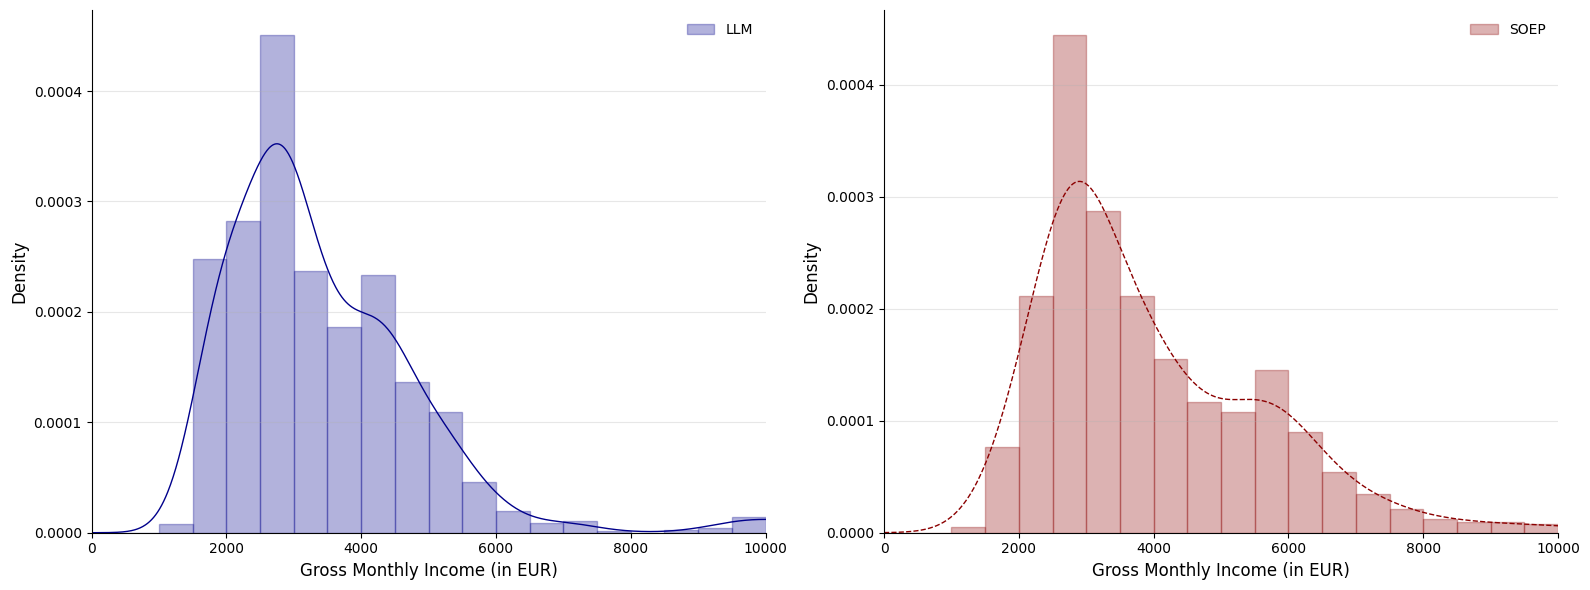

In [174]:
# Plot weighted wage distributions with 500 euro bins and density functions
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define bins of 500 euros
min_wage = 0
max_wage = 10000
bins = np.arange(0, max_wage + 500, 500)

# Plot OpenAI wage distribution (weighted)
counts, _, patches = axes[0].hist(valid_df['llm_income_mean'], bins=bins, weights=valid_df['n_obs'], 
                                   alpha=0.3, color='darkblue', edgecolor='darkblue', label='LLM', density=True)
# Add KDE
kde_openai = gaussian_kde(valid_df['llm_income_mean'], weights=valid_df['n_obs'])
x_range_openai = np.linspace(0, 10000, 1000)
axes[0].plot(x_range_openai, kde_openai(x_range_openai), color='darkblue', linewidth=1, linestyle='-')
axes[0].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_xlim(0, 10000)
axes[0].legend(frameon=False, fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Plot SOEP wage distribution (weighted)
counts, _, patches = axes[1].hist(valid_df['pglabgro_mean'], bins=bins, weights=valid_df['n_obs'], 
                                   alpha=0.3, color='darkred', edgecolor='darkred', label='SOEP', density=True)
# Add KDE
kde_soep = gaussian_kde(valid_df['pglabgro_mean'], weights=valid_df['n_obs'])
x_range = np.linspace(0, 10000, 1000)
axes[1].plot(x_range, kde_soep(x_range), color='darkred', linewidth=1, linestyle='--')
axes[1].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_xlim(0, 10000)
axes[1].legend(frameon=False, fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

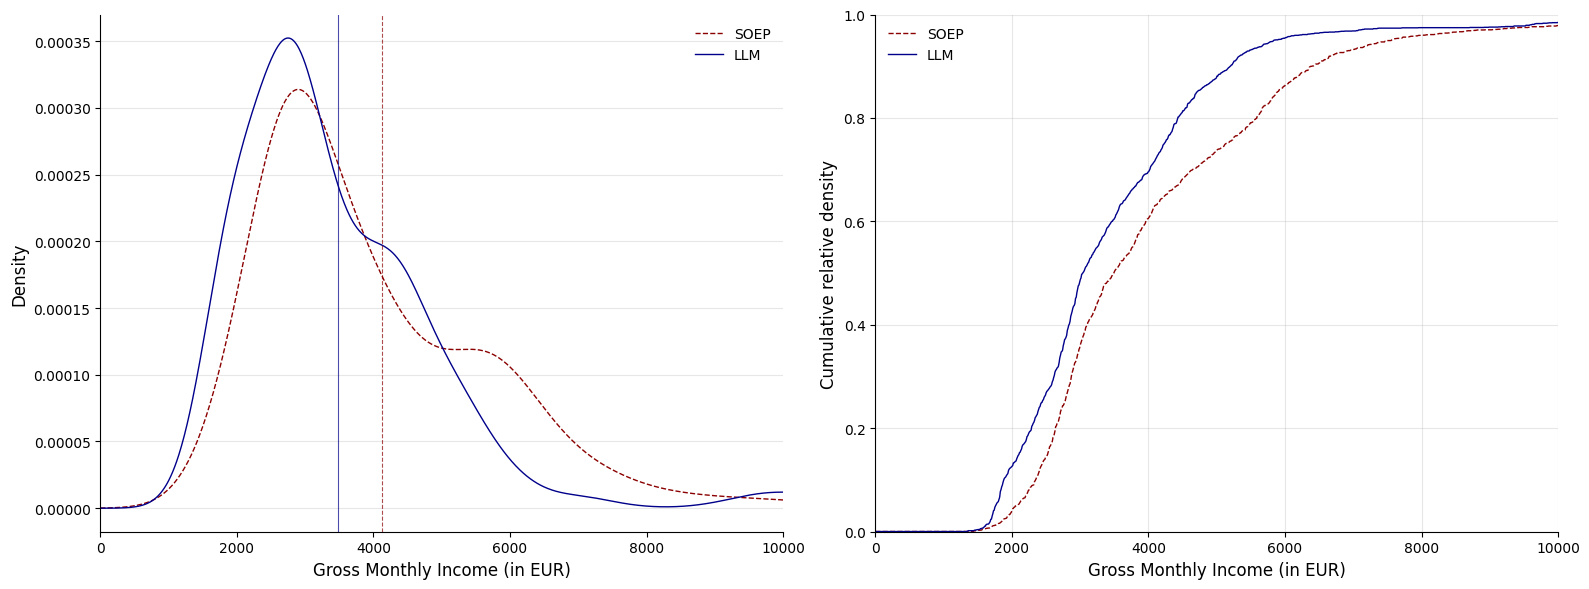

In [175]:
# Create density and cumulative density plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate weighted averages
soep_mean = np.average(valid_df['pglabgro_mean'], weights=valid_df['n_obs'])
openai_mean = np.average(valid_df['llm_income_mean'], weights=valid_df['n_obs'])

# Left panel: Density functions only
x_range_plot = np.linspace(0, 10000, 1000)
axes[0].plot(x_range_plot, kde_soep(x_range_plot), color='darkred', linewidth=1, linestyle='--', label='SOEP')
axes[0].plot(x_range_plot, kde_openai(x_range_plot), color='darkblue', linewidth=1, linestyle='-', label='LLM')

# Add vertical lines for averages
axes[0].axvline(soep_mean, color='darkred', linewidth=0.8, linestyle='--', alpha=0.7)
axes[0].axvline(openai_mean, color='darkblue', linewidth=0.8, linestyle='-', alpha=0.7)

axes[0].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_xlim(0, 10000)
axes[0].legend(fontsize=10, frameon=False)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Cumulative density functions
# Calculate empirical CDFs using weighted observations
def weighted_ecdf(data, weights, x_eval):
    """Calculate weighted empirical CDF at evaluation points."""
    sorted_indices = np.argsort(data)
    sorted_data = data[sorted_indices]
    sorted_weights = weights[sorted_indices]
    cumsum_weights = np.cumsum(sorted_weights)
    total_weight = cumsum_weights[-1]
    
    # Normalize to [0, 1]
    cumsum_weights = cumsum_weights / total_weight
    
    # Evaluate at x_eval points
    cdf_values = np.searchsorted(sorted_data, x_eval, side='right')
    cdf_values = np.clip(cdf_values - 1, 0, len(cumsum_weights) - 1)
    
    result = np.zeros(len(x_eval))
    for i, idx in enumerate(cdf_values):
        if idx >= 0:
            result[i] = cumsum_weights[idx]
    
    return result

cdf_soep = weighted_ecdf(valid_df['pglabgro_mean'].values, valid_df['n_obs'].values, x_range_plot)
cdf_openai = weighted_ecdf(valid_df['llm_income_mean'].values, valid_df['n_obs'].values, x_range_plot)

axes[1].plot(x_range_plot, cdf_soep, color='darkred', linewidth=1, linestyle='--', label='SOEP')
axes[1].plot(x_range_plot, cdf_openai, color='darkblue', linewidth=1, linestyle='-', label='LLM')

axes[1].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[1].set_ylabel('Cumulative relative density', fontsize=12)
axes[1].set_xlim(0, 10000)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=10, frameon=False)
axes[1].grid(True, alpha=0.3)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation between SOEP and LLM income data

In [176]:
# Compute correlation coefficient (weighted by n_obs)

# Weighted correlation using numpy
weights = valid_df['n_obs'].values
weighted_cov = np.cov(valid_df['llm_income_mean'], valid_df['pglabgro_mean'], aweights=weights)
correlation = weighted_cov[0, 1] / np.sqrt(weighted_cov[0, 0] * weighted_cov[1, 1])

# Also compute unweighted for comparison
unweighted_corr = valid_df['llm_income_mean'].corr(valid_df['pglabgro_mean'])

print(f"Weighted correlation coefficient: {correlation:.4f}")
print(f"Unweighted correlation coefficient: {unweighted_corr:.4f}")
print(f"\nNumber of groups: {len(valid_df)}")
print(f"Total weighted observations: {valid_df['n_obs'].sum():.0f}")

Weighted correlation coefficient: 0.7807
Unweighted correlation coefficient: 0.7351

Number of groups: 1721
Total weighted observations: 17358


In [177]:
# Compute spearman correlation
from scipy.stats import spearmanr

spearman_unweighted = valid_df[['llm_income_mean', 'pglabgro_mean']].corr(method='spearman')
unweighted_rho = spearman_unweighted.loc['llm_income_mean', 'pglabgro_mean']

print(f"Spearman correlation coefficient (unweighted): {unweighted_rho:.4f}")

Spearman correlation coefficient (unweighted): 0.8334


## Income ranking (SOEP vs LLM)

## Measurement error distributions
Measurement error is defined as the difference between LLM estimates and the true survey labor income.

In [178]:
# Measurement error descriptives (weighted by n_obs)
me = valid_df['measurement_error']
me_log = valid_df['measurement_error_log']


weights = valid_df['n_obs']
print(f"Number of observations: {len(me_log)}")

print(f"Total weighted observations: {weights.sum():.0f}")

print("Weighted Measurement Error Statistics (EUR):")
print(f"  Median (approx): {me.median():.4f}")

print(f"  Mean: {np.average(me, weights=weights):.4f}")
print(f"  Max: {me.max():.4f}")

print(f"  Std: {np.sqrt(np.average((me - np.average(me, weights=weights))**2, weights=weights)):.4f}")
print(f"  Min: {me.min():.4f}")

print("Weighted Measurement Error Statistics (log points):")
print(f"  Median (approx): {me_log.median():.4f}")

print(f"  Mean: {np.average(me_log, weights=weights):.4f}")
print(f"  Max: {me_log.max():.4f}")

print(f"  Std: {np.sqrt(np.average((me_log - np.average(me_log, weights=weights))**2, weights=weights)):.4f}")
print(f"  Min: {me_log.min():.4f}")

Number of observations: 1721
Total weighted observations: 17358
Weighted Measurement Error Statistics (EUR):
  Median (approx): -481.5000
  Mean: -646.9116
  Max: 7293.3333
  Std: 1310.1322
  Min: -15683.3333
Weighted Measurement Error Statistics (log points):
  Median (approx): -0.1572
  Mean: -0.1641
  Max: 1.0195
  Std: 0.2259
  Min: -1.4963


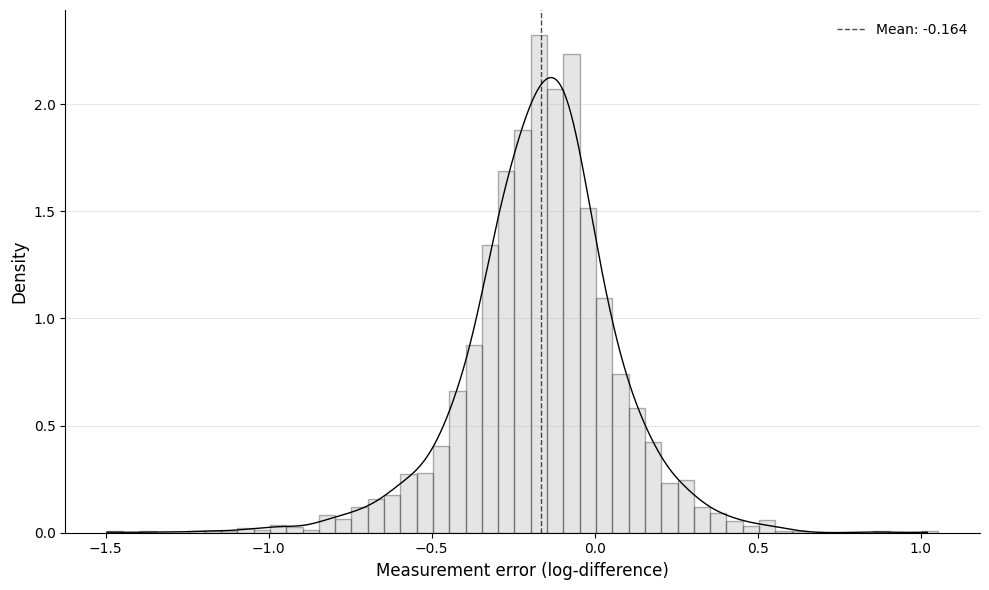

In [179]:
# Plot measurement error distribution in logs
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Calculate weighted mean of measurement error
me_mean = np.average(valid_df['measurement_error_log'], weights=valid_df['n_obs'])

# Define bins of 0.05
bins = np.arange(valid_df['measurement_error_log'].min(), valid_df['measurement_error_log'].max() + 0.05, 0.05)

# Plot histogram
ax.hist(valid_df['measurement_error_log'], bins=bins, weights=valid_df['n_obs'], 
        alpha=0.3, color='darkgrey', edgecolor='black', density=True)

# Add KDE
kde_me = gaussian_kde(valid_df['measurement_error_log'], weights=valid_df['n_obs'])
x_range = np.linspace(valid_df['measurement_error_log'].min(), valid_df['measurement_error_log'].max(), 1000)
ax.plot(x_range, kde_me(x_range), color='black', linewidth=1, linestyle='-')

# Add vertical line for mean
ax.axvline(me_mean, color='black', linewidth=1, linestyle='--', alpha=0.7, label=f'Mean: {me_mean:.3f}')

ax.set_xlabel('Measurement error (log-difference)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


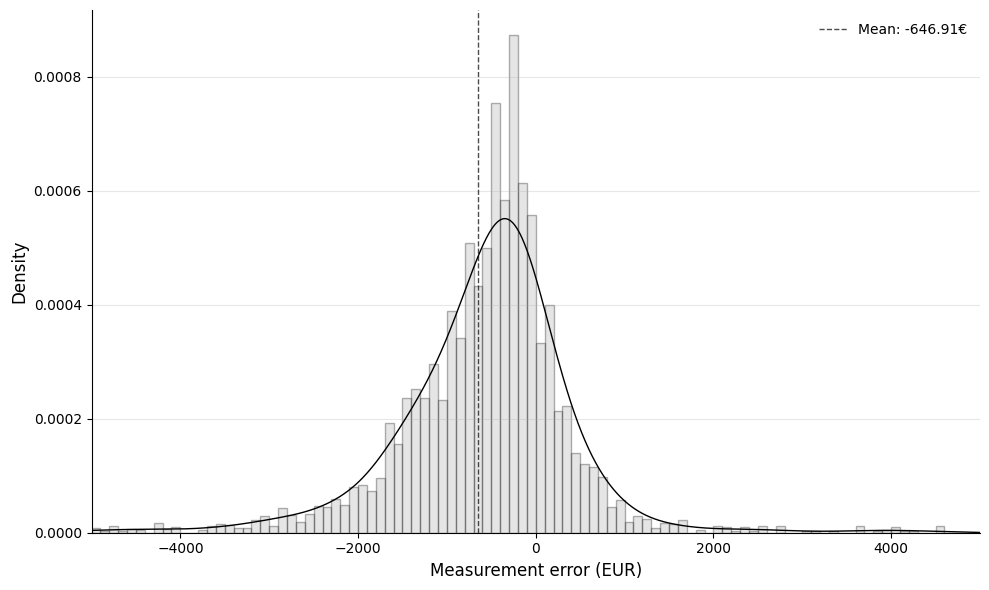

In [180]:
# Plot nominal measurement error distribution
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Calculate weighted mean of measurement error
me_mean = np.average(valid_df['measurement_error'], weights=valid_df['n_obs'])

# Define bins (50 euro bins) and limit range to -5000 to +5000
bin_width = 100
bins = np.arange(-5000, 5000 + bin_width, bin_width)

# Plot histogram
ax.hist(valid_df['measurement_error'], bins=bins, weights=valid_df['n_obs'], 
        alpha=0.3, color='darkgrey', edgecolor='black', density=True)

# Add KDE
kde_me = gaussian_kde(valid_df['measurement_error'], weights=valid_df['n_obs'])
x_range = np.linspace(-5000, 5000, 1000)
ax.plot(x_range, kde_me(x_range), color='black', linewidth=1, linestyle='-')

# Add vertical line for mean
ax.axvline(me_mean, color='black', linewidth=1, linestyle='--', alpha=0.7, label=f'Mean: {me_mean:.2f}€')

ax.set_xlabel('Measurement error (EUR)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(-5000, 5000)
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


/var/folders/5h/mgjr5c410p33q26211w0wr640000gn/T/ipykernel_29007/3803211000.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_stats_euro = valid_df.groupby('income_quantile').agg({
/var/folders/5h/mgjr5c410p33q26211w0wr640000gn/T/ipykernel_29007/3803211000.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_stats_log = valid_df.groupby('income_quantile').agg({


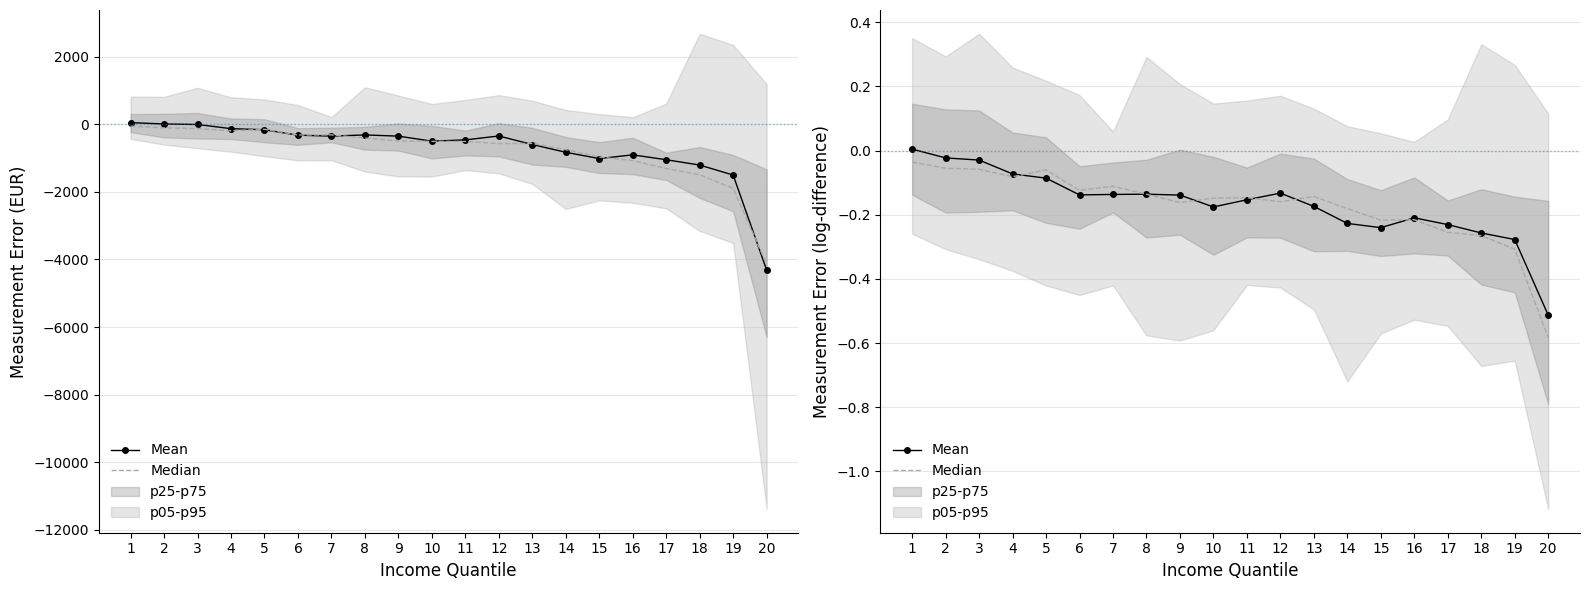

In [181]:
# Measurement error distribution by earning quantiles

# Create 20 quantiles based on SOEP earnings
valid_df['income_quantile'] = pd.qcut(valid_df['pglabgro_mean'], q=20, labels=range(1, 21))

# Calculate statistics for each quantile (in euros)
quantile_stats_euro = valid_df.groupby('income_quantile').agg({
    'measurement_error': ['mean', 'median', 
                          lambda x: x.quantile(0.05),
                          lambda x: x.quantile(0.25), 
                          lambda x: x.quantile(0.75),
                          lambda x: x.quantile(0.95)]
}).reset_index()
quantile_stats_euro.columns = ['quantile', 'mean', 'median', 'p05', 'p25', 'p75', 'p95']

# Calculate statistics for each quantile (in logs)
quantile_stats_log = valid_df.groupby('income_quantile').agg({
    'measurement_error_log': ['mean', 'median',
                              lambda x: x.quantile(0.05),
                              lambda x: x.quantile(0.25),
                              lambda x: x.quantile(0.75),
                              lambda x: x.quantile(0.95)]
}).reset_index()
quantile_stats_log.columns = ['quantile', 'mean', 'median', 'p05', 'p25', 'p75', 'p95']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Measurement error in euros
axes[0].fill_between(quantile_stats_euro['quantile'], quantile_stats_euro['p05'], quantile_stats_euro['p95'],
                      alpha=0.2, color='grey', label='p05-p95')
axes[0].fill_between(quantile_stats_euro['quantile'], quantile_stats_euro['p25'], quantile_stats_euro['p75'],
                      alpha=0.3, color='grey', label='p25-p75')
axes[0].plot(quantile_stats_euro['quantile'], quantile_stats_euro['mean'], 
             color='black', linewidth=1, linestyle='-', marker='o', markersize=4, label='Mean')
axes[0].plot(quantile_stats_euro['quantile'], quantile_stats_euro['median'],
             color='darkgrey', linewidth=1, linestyle='--', markersize=4, label='Median')
axes[0].axhline(0, linewidth=1, linestyle=':', alpha=0.5)
axes[0].set_xlabel('Income Quantile', fontsize=12)
axes[0].set_ylabel('Measurement Error (EUR)', fontsize=12)
axes[0].set_xticks(range(1, 21))
axes[0].set_xticklabels(range(1, 21))
# Reorder legend: mean, median, p25-p75, p05-p95
handles, labels = axes[0].get_legend_handles_labels()
order = [2, 3, 1, 0]  # mean, median, p25-p75, p05-p95
axes[0].legend([handles[i] for i in order], [labels[i] for i in order], fontsize=10, frameon=False)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Measurement error in logs
axes[1].fill_between(quantile_stats_log['quantile'], quantile_stats_log['p05'], quantile_stats_log['p95'],
                      alpha=0.2, color='grey', label='p05-p95')
axes[1].fill_between(quantile_stats_log['quantile'], quantile_stats_log['p25'], quantile_stats_log['p75'],
                      alpha=0.3, color='grey', label='p25-p75')
axes[1].plot(quantile_stats_log['quantile'], quantile_stats_log['mean'],
             color='black', linewidth=1, linestyle='-', marker='o', markersize=4, label='Mean')
axes[1].plot(quantile_stats_log['quantile'], quantile_stats_log['median'],
             color='darkgrey', linewidth=1, linestyle='--', markersize=4, label='Median')
axes[1].axhline(0, linewidth=1, linestyle=':', alpha=0.5)
axes[1].set_xlabel('Income Quantile', fontsize=12)
axes[1].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[1].set_xticks(range(1, 21))
axes[1].set_xticklabels(range(1, 21))
# Reorder legend: mean, median, p25-p75, p05-p95
handles, labels = axes[1].get_legend_handles_labels()
order = [2, 3, 1, 0]  # mean, median, p25-p75, p05-p95
axes[1].legend([handles[i] for i in order], [labels[i] for i in order], fontsize=10, frameon=False)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


## Correlation with observables and Mincer regressions

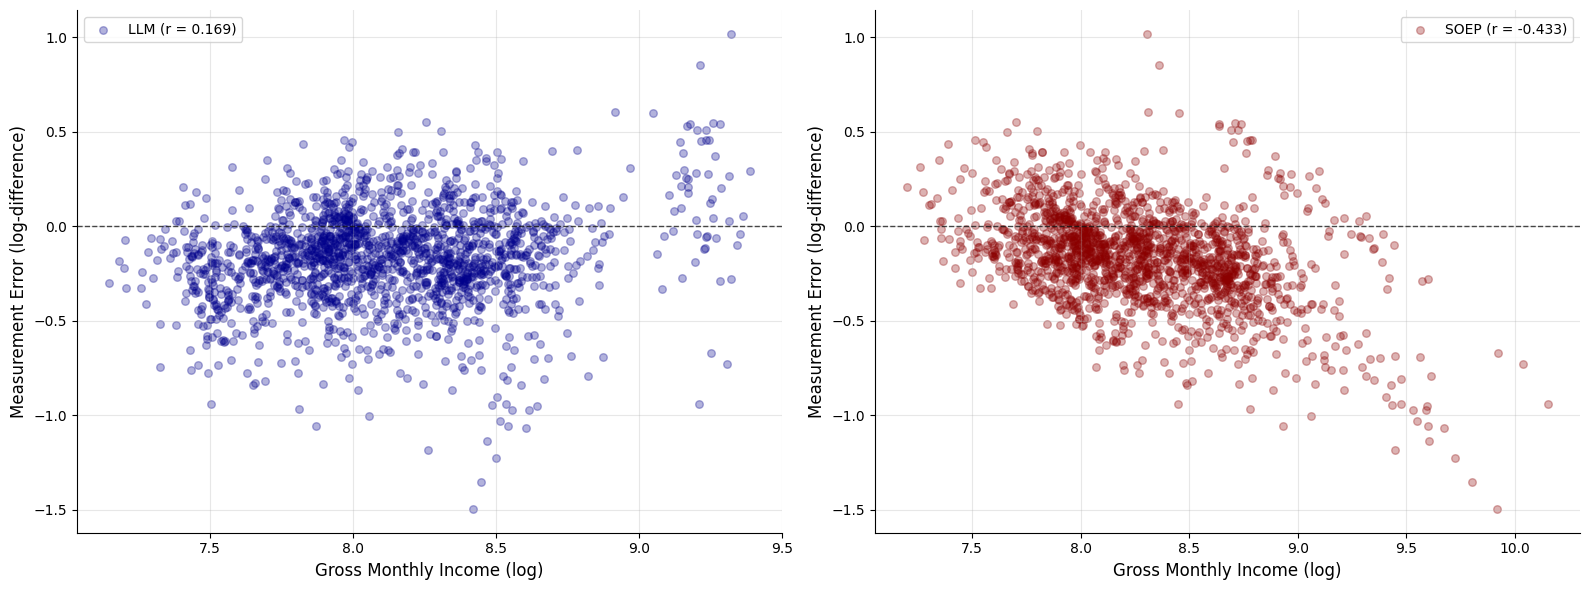

In [182]:
# Scatter plot: Measurement error vs income levels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate correlations
corr_llm = valid_df['log_llm_income_mean'].corr(valid_df['measurement_error_log'])
corr_soep = valid_df['log_pglabgro_mean'].corr(valid_df['measurement_error_log'])

# Left panel: Measurement error vs LLM income
axes[0].scatter(valid_df['log_llm_income_mean'], valid_df['measurement_error_log'], 
                alpha=0.3, color='darkblue', s=30, label=f'LLM (r = {corr_llm:.3f})')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
axes[0].set_xlabel('Gross Monthly Income (log)', fontsize=12)
axes[0].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[0].legend(fontsize=10, frameon=True)
axes[0].grid(True, alpha=0.3)
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Measurement error vs SOEP income
axes[1].scatter(valid_df['log_pglabgro_mean'], valid_df['measurement_error_log'], 
                alpha=0.3, color='darkred', s=30, label=f'SOEP (r = {corr_soep:.3f})')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
axes[1].set_xlabel('Gross Monthly Income (log)', fontsize=12)
axes[1].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[1].legend(fontsize=10, frameon=True)
axes[1].grid(True, alpha=0.3)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

In [183]:
# Regression of measurement error on true SOEP earnings
# This tests whether measurement error is systematically related to earnings level

# Prepare regression data
X_soep = valid_df[['log_pglabgro_mean']].copy()
X_soep = sm.add_constant(X_soep)
y_me = valid_df['measurement_error_log'].values
weights_me = valid_df['n_obs'].values

# Fit weighted OLS with robust standard errors
model_me_on_soep = sm.WLS(y_me, X_soep, weights=weights_me)
results_me_on_soep = model_me_on_soep.fit(cov_type='HC3')

# Print regression results
print("="*80)
print("Weighted OLS: Measurement Error (log) on True SOEP Earnings (log)")
print("="*80)
print(results_me_on_soep.summary())
print("\n")

# Calculate R-squared
print(f"R-squared: {results_me_on_soep.rsquared:.4f}")
print(f"Adjusted R-squared: {results_me_on_soep.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_me = results_me_on_soep.predict(X_soep)
rmse_me = np.sqrt(mean_squared_error(y_me, y_pred_me, sample_weight=weights_me))
mae_me = mean_absolute_error(y_me, y_pred_me, sample_weight=weights_me)

print(f"Weighted RMSE: {rmse_me:.4f}")
print(f"Weighted MAE: {mae_me:.4f}")
print("\n")

# Interpret the coefficient
beta_soep = results_me_on_soep.params['log_pglabgro_mean']
se_soep = results_me_on_soep.bse['log_pglabgro_mean']
pval_soep = results_me_on_soep.pvalues['log_pglabgro_mean']

print(f"Coefficient on log(SOEP earnings): {beta_soep:.4f} (SE: {se_soep:.4f}, p-value: {pval_soep:.4e})")
if pval_soep < 0.001:
    sig_str = "***"
elif pval_soep < 0.01:
    sig_str = "**"
elif pval_soep < 0.05:
    sig_str = "*"
else:
    sig_str = ""
print(f"Significance: {sig_str}")
print("\n")

# Interpretation
if abs(beta_soep) < 0.01:
    print("The measurement error is essentially unrelated to true earnings level.")
elif beta_soep > 0:
    print(f"The measurement error INCREASES by {beta_soep:.4f} log points for each 1 log point")
    print("increase in true SOEP earnings. LinkedIn-LLM estimates tend to OVERESTIMATE")
    print("earnings more for higher earners (or underestimate less).")
else:
    print(f"The measurement error DECREASES by {abs(beta_soep):.4f} log points for each 1 log point")
    print("increase in true SOEP earnings. LinkedIn-LLM estimates tend to UNDERESTIMATE")
    print("earnings more for higher earners (or overestimate less).")
print("="*80)

Weighted OLS: Measurement Error (log) on True SOEP Earnings (log)
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.154
Model:                            WLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     194.7
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           5.41e-42
Time:                        19:01:13   Log-Likelihood:                 122.79
No. Observations:                1721   AIC:                            -241.6
Df Residuals:                    1719   BIC:                            -230.7
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [184]:
# Regression of measurement error (in euros) on true SOEP earnings (in euros)
# This tests whether measurement error in nominal terms is systematically related to earnings level

# Prepare regression data
X_soep_euro = valid_df[['pglabgro_mean']].copy()
X_soep_euro = sm.add_constant(X_soep_euro)
y_me_euro = valid_df['measurement_error'].values
weights_me_euro = valid_df['n_obs'].values

# Fit weighted OLS with robust standard errors
model_me_on_soep_euro = sm.WLS(y_me_euro, X_soep_euro, weights=weights_me_euro)
results_me_on_soep_euro = model_me_on_soep_euro.fit(cov_type='HC3')

# Print regression results
print("="*80)
print("Weighted OLS: Measurement Error (EUR) on True SOEP Earnings (EUR)")
print("="*80)
print(results_me_on_soep_euro.summary())
print("\n")

# Calculate R-squared
print(f"R-squared: {results_me_on_soep_euro.rsquared:.4f}")
print(f"Adjusted R-squared: {results_me_on_soep_euro.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_me_euro = results_me_on_soep_euro.predict(X_soep_euro)
rmse_me_euro = np.sqrt(mean_squared_error(y_me_euro, y_pred_me_euro, sample_weight=weights_me_euro))
mae_me_euro = mean_absolute_error(y_me_euro, y_pred_me_euro, sample_weight=weights_me_euro)

print(f"Weighted RMSE: {rmse_me_euro:.2f}€")
print(f"Weighted MAE: {mae_me_euro:.2f}€")
print("\n")

# Interpret the coefficient
beta_soep_euro = results_me_on_soep_euro.params['pglabgro_mean']
se_soep_euro = results_me_on_soep_euro.bse['pglabgro_mean']
pval_soep_euro = results_me_on_soep_euro.pvalues['pglabgro_mean']

print(f"Coefficient on SOEP earnings: {beta_soep_euro:.4f} (SE: {se_soep_euro:.4f}, p-value: {pval_soep_euro:.4e})")
if pval_soep_euro < 0.001:
    sig_str = "***"
elif pval_soep_euro < 0.01:
    sig_str = "**"
elif pval_soep_euro < 0.05:
    sig_str = "*"
else:
    sig_str = ""
print(f"Significance: {sig_str}")
print("\n")

# Interpretation
if abs(beta_soep_euro) < 0.01:
    print("The measurement error is essentially unrelated to true earnings level.")
elif beta_soep_euro > 0:
    print(f"The measurement error INCREASES by {beta_soep_euro:.4f}€ for each 1€")
    print("increase in true SOEP earnings. LinkedIn-LLM estimates tend to OVERESTIMATE")
    print("earnings more for higher earners (or underestimate less).")
else:
    print(f"The measurement error DECREASES by {abs(beta_soep_euro):.4f}€ for each 1€")
    print("increase in true SOEP earnings. LinkedIn-LLM estimates tend to UNDERESTIMATE")
    print("earnings more for higher earners (or overestimate less).")
print("="*80)

Weighted OLS: Measurement Error (EUR) on True SOEP Earnings (EUR)
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.425
Model:                            WLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     199.0
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           7.78e-43
Time:                        19:01:13   Log-Likelihood:                -14458.
No. Observations:                1721   AIC:                         2.892e+04
Df Residuals:                    1719   BIC:                         2.893e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

In [185]:
valid_df['llm_income_mean'].value_counts().sort_index().tail(50)

llm_income_mean
8916.666667     1
8988.095238     1
9125.000000     1
9166.666667     1
9226.190476     1
9343.750000     1
9356.060606     1
9519.927536     1
9583.333333     1
9583.333333     2
9611.111111     1
9656.250000     1
9659.090909     1
9677.083333     1
9772.727273     1
9843.750000     1
9861.111111     1
9916.666667     1
10000.000000    2
10041.666667    1
10054.166667    1
10059.523810    1
10083.333333    1
10138.888889    1
10156.250000    1
10203.703704    1
10277.777778    1
10277.777778    1
10300.000000    1
10333.333333    1
10341.666667    1
10416.666667    2
10416.666667    1
10486.111111    1
10535.714286    1
10572.916667    1
10625.000000    1
10661.764706    1
10730.769231    1
10833.333333    1
10833.333333    1
10937.500000    1
11111.111111    1
11212.121212    1
11250.000000    2
11333.333333    1
11458.333333    1
11750.000000    1
11805.555556    1
12000.000000    1
Name: count, dtype: int64

In [186]:
# Prepare dataframes

covariates = ['sex_en', 'education_grouped', 'state_en', 'isco_3_name', 'syear', 'pgexpft_mean', 'pgexpft_sq_mean']

# Prepare the data for regression - drop any rows with missing values in key variables
regression_df = valid_df[['measurement_error_log', 'log_llm_income_mean', 'log_pglabgro_mean', 'n_obs'] + covariates].dropna().copy()
regression_df['syear'] = regression_df['syear'].astype(str)

print(f"Observations for regression: {len(regression_df)}")
print(f"Weighted observations: {regression_df['n_obs'].sum():.0f}")

Observations for regression: 1721
Weighted observations: 17358


In [187]:
# Regression of measurement error (log) on covariates

# Combine all features
X = pd.get_dummies(regression_df[covariates], drop_first=True, dtype=float)

# Add constant
X = sm.add_constant(X)

# Dependent variable
y = regression_df['measurement_error_log'].values

# Weights
weights = regression_df['n_obs'].values

# Fit weighted OLS with robust standard errors
model = sm.WLS(y, X, weights=weights)
results = model.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("Weighted OLS Regression: Measurement Error (log) on Covariates")
print("="*80)
print(results.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results.params)) if i != 0]
f_test = results.f_test(np.eye(len(results.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test.fvalue:.4f}")
print(f"P-value: {f_test.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred = results.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred, sample_weight=weights))
mae = mean_absolute_error(y, y_pred, sample_weight=weights)

print(f"Weighted RMSE: {rmse:.4f}")
print(f"Weighted MAE: {mae:.4f}")
print("="*80)

Weighted OLS Regression: Measurement Error (log) on Covariates
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.563
Model:                            WLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     27.81
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          4.36e-272
Time:                        19:01:13   Log-Likelihood:                 691.24
No. Observations:                1721   AIC:                            -1192.
Df Residuals:                    1626   BIC:                            -674.7
Df Model:                          94                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z      P>|z|      [0.0

In [188]:
# Regression of log_llm_income_mean on covariates
# Using the same feature matrix X from the previous regression

# Dependent variable - log LLM income
y_llm = regression_df['log_llm_income_mean'].values

# Fit weighted OLS with robust standard errors (using same X and weights)
model_llm = sm.WLS(y_llm, X, weights=weights)
results_llm = model_llm.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("Weighted OLS Regression: log(LLM Income) on Covariates")
print("="*80)
print(results_llm.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results_llm.params)) if i != 0]
f_test_llm = results_llm.f_test(np.eye(len(results_llm.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test_llm.fvalue:.4f}")
print(f"P-value: {f_test_llm.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results_llm.rsquared:.4f}")
print(f"Adjusted R-squared: {results_llm.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_llm = results_llm.predict(X)
rmse_llm = np.sqrt(mean_squared_error(y_llm, y_pred_llm, sample_weight=weights))
mae_llm = mean_absolute_error(y_llm, y_pred_llm, sample_weight=weights)

print(f"Weighted RMSE: {rmse_llm:.4f}")
print(f"Weighted MAE: {mae_llm:.4f}")
print("="*80)

Weighted OLS Regression: log(LLM Income) on Covariates
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.985
Model:                            WLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     1089.
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:01:13   Log-Likelihood:                 2642.1
No. Observations:                1721   AIC:                            -5094.
Df Residuals:                    1626   BIC:                            -4576.
Df Model:                          94                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z      P>|z|      [0.025      

In [189]:
# Regression of log_pglabgro_mean (SOEP wages) on covariates
# Using the same feature matrix X from the previous regressions

# Dependent variable - log SOEP income
y_soep = regression_df['log_pglabgro_mean'].values

# Fit weighted OLS with robust standard errors (using same X and weights)
model_soep = sm.WLS(y_soep, X, weights=weights)
results_soep = model_soep.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("Weighted OLS Regression: log(SOEP Income) on Covariates")
print("="*80)
print(results_soep.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results_soep.params)) if i != 0]
f_test_soep = results_soep.f_test(np.eye(len(results_soep.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test_soep.fvalue:.4f}")
print(f"P-value: {f_test_soep.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results_soep.rsquared:.4f}")
print(f"Adjusted R-squared: {results_soep.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_soep = results_soep.predict(X)
rmse_soep = np.sqrt(mean_squared_error(y_soep, y_pred_soep, sample_weight=weights))
mae_soep = mean_absolute_error(y_soep, y_pred_soep, sample_weight=weights)

print(f"Weighted RMSE: {rmse_soep:.4f}")
print(f"Weighted MAE: {mae_soep:.4f}")
print("="*80)

Weighted OLS Regression: log(SOEP Income) on Covariates
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.885
Model:                            WLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     163.0
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:01:14   Log-Likelihood:                 771.27
No. Observations:                1721   AIC:                            -1353.
Df Residuals:                    1626   BIC:                            -834.7
Df Model:                          94                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z      P>|z|      [0.025     

In [190]:
# Create comparison table of regression results

# Function to format coefficient with std error and significance
def format_coef(coef, se, pval):
    """Format coefficient with standard error and significance stars"""
    stars = ''
    if pval < 0.001:
        stars = '***'
    elif pval < 0.01:
        stars = '**'
    elif pval < 0.05:
        stars = '*'
    return f"{coef:.4f}{stars}\n({se:.4f})"

# Extract parameters from all three models
params_me = results.params
se_me = results.bse
pval_me = results.pvalues

params_llm = results_llm.params
se_llm = results_llm.bse
pval_llm = results_llm.pvalues

params_soep = results_soep.params
se_soep = results_soep.bse
pval_soep = results_soep.pvalues

# Create list of rows for the table
table_data = []

# Group variables by type
sex_vars = [v for v in params_me.index if v.startswith('sex_')]
education_vars = [v for v in params_me.index if v.startswith('education_')]
occupation_vars = [v for v in params_me.index if v.startswith('occupation_')]
state_vars = [v for v in params_me.index if v.startswith('state_')]
year_vars = [v for v in params_me.index if v.startswith('syear_')]
experience_vars = ['pgexpft_mean', 'pgexpft_sq_mean']

# Add constant
if 'const' in params_me.index:
    table_data.append({
        'Variable': 'Constant',
        'Measurement Error': format_coef(params_me['const'], se_me['const'], pval_me['const']),
        'LLM Income': format_coef(params_llm['const'], se_llm['const'], pval_llm['const']),
        'SOEP Income': format_coef(params_soep['const'], se_soep['const'], pval_soep['const'])
    })

# Add experience variables
table_data.append({'Variable': '--- Experience ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
for var in experience_vars:
    if var in params_me.index:
        table_data.append({
            'Variable': var,
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add sex variables
if sex_vars:
    table_data.append({'Variable': '--- Sex ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var in sex_vars:
        table_data.append({
            'Variable': var.replace('sex_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add education variables
if education_vars:
    table_data.append({'Variable': '--- Education ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var in education_vars:
        table_data.append({
            'Variable': var.replace('education_grouped_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add top 5 occupation variables by absolute coefficient value (using measurement error)
if occupation_vars:
    occ_abs_coefs = {var: abs(params_me[var]) for var in occupation_vars}
    top_5_occ = sorted(occ_abs_coefs.items(), key=lambda x: x[1], reverse=True)[:5]
    table_data.append({'Variable': '--- Occupation (Top 5) ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var, _ in top_5_occ:
        table_data.append({
            'Variable': var.replace('occupation_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add top 5 state variables by absolute coefficient value (using measurement error)
if state_vars:
    state_abs_coefs = {var: abs(params_me[var]) for var in state_vars}
    top_5_state = sorted(state_abs_coefs.items(), key=lambda x: x[1], reverse=True)[:5]
    table_data.append({'Variable': '--- State (Top 5) ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var, _ in top_5_state:
        table_data.append({
            'Variable': var.replace('state_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add model statistics
table_data.append({'Variable': '', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
table_data.append({'Variable': '--- Model Statistics ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})

# Time fixed effects
time_fe = 'Yes' if year_vars else 'No'
table_data.append({
    'Variable': 'Time Fixed Effects',
    'Measurement Error': time_fe,
    'LLM Income': time_fe,
    'SOEP Income': time_fe
})

# F-statistic
table_data.append({
    'Variable': 'F-statistic',
    'Measurement Error': f"{f_test.fvalue:.2f}",
    'LLM Income': f"{f_test_llm.fvalue:.2f}",
    'SOEP Income': f"{f_test_soep.fvalue:.2f}"
})

# R-squared
table_data.append({
    'Variable': 'R-squared',
    'Measurement Error': f"{results.rsquared:.4f}",
    'LLM Income': f"{results_llm.rsquared:.4f}",
    'SOEP Income': f"{results_soep.rsquared:.4f}"
})

# Number of observations
table_data.append({
    'Variable': 'Observations',
    'Measurement Error': f"{int(results.nobs)}",
    'LLM Income': f"{int(results_llm.nobs)}",
    'SOEP Income': f"{int(results_soep.nobs)}"
})

# Create DataFrame and display
comparison_table = pd.DataFrame(table_data)
print("="*100)
print("REGRESSION RESULTS COMPARISON")
print("="*100)
print("\nNote: Standard errors in parentheses. *** p<0.001, ** p<0.01, * p<0.05")
print("\n")
print(comparison_table.to_string(index=False))
print("\n" + "="*100)

REGRESSION RESULTS COMPARISON

Note: Standard errors in parentheses. *** p<0.001, ** p<0.01, * p<0.05


                                                     Variable    Measurement Error           LLM Income          SOEP Income
                                                     Constant    -0.1017\n(0.0745)  8.0201***\n(0.0222)  8.1218***\n(0.0692)
                                           --- Experience ---                                                               
                                                 pgexpft_mean -0.0330***\n(0.0053)     0.0011\n(0.0016)  0.0341***\n(0.0051)
                                              pgexpft_sq_mean  0.0591***\n(0.0137)     0.0040\n(0.0042) -0.0550***\n(0.0131)
                                                  --- Sex ---                                                               
                                                      en_male -0.0863***\n(0.0150)  0.0801***\n(0.0047)  0.1664***\n(0.0147)
                     

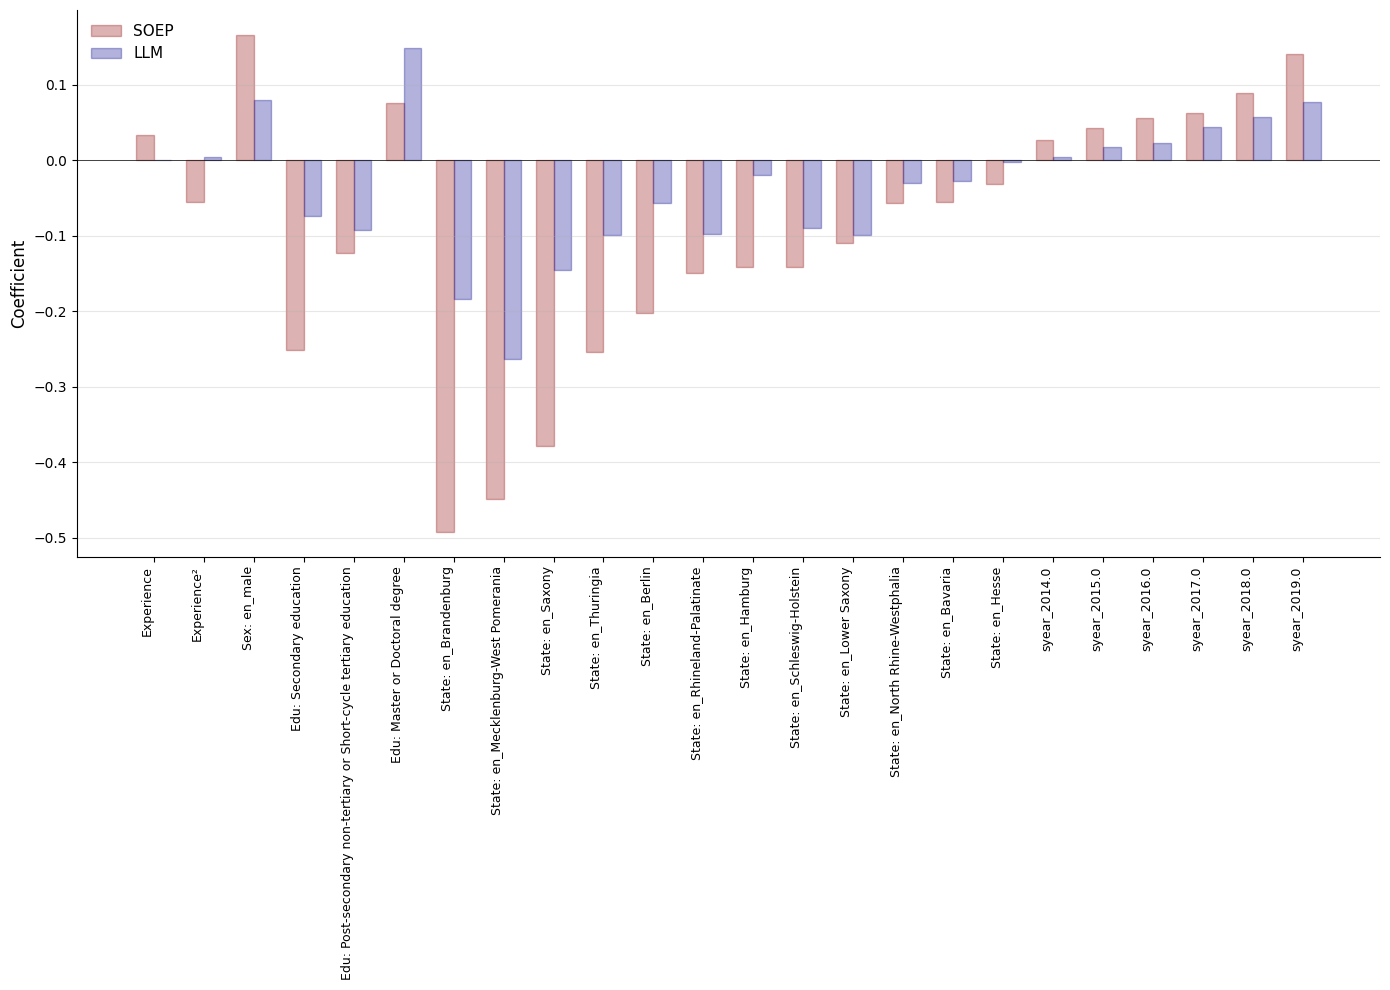

In [191]:
# Visualize coefficient comparison between LLM and SOEP

# Extract coefficients for variables of interest
experience_vars = ['pgexpft_mean', 'pgexpft_sq_mean']
sex_vars = [v for v in params_llm.index if v.startswith('sex_')]
education_vars = [v for v in params_llm.index if v.startswith('education_')]
state_vars = [v for v in params_llm.index if v.startswith('state_')]
year_vars = [v for v in params_llm.index if v.startswith('syear_')]

# Sort each category by absolute SOEP coefficient value
sex_vars_sorted = sorted(sex_vars, key=lambda x: abs(params_soep[x]), reverse=True)
education_vars_sorted = sorted(education_vars, key=lambda x: abs(params_soep[x]), reverse=True)
state_vars_sorted = sorted(state_vars, key=lambda x: abs(params_soep[x]), reverse=True)

# Combine all variables (experience stays in original order)
plot_vars = experience_vars + sex_vars_sorted + education_vars_sorted + state_vars_sorted + year_vars

# Create labels (clean variable names)
labels = []
llm_coefs = []
soep_coefs = []

for var in plot_vars:
    if var in params_llm.index and var in params_soep.index:
        # Clean up variable name for display
        if var.startswith('sex_'):
            label = var.replace('sex_', 'Sex: ')
        elif var.startswith('education_'):
            label = var.replace('education_grouped_', 'Edu: ')
        elif var.startswith('state_'):
            label = var.replace('state_', 'State: ')
        elif var == 'pgexpft_mean':
            label = 'Experience'
        elif var == 'pgexpft_sq_mean':
            label = 'Experience²'
        elif var == 'syear_':
            label = var.replace('syear_', 'Year: ')
        else:
            label = var
        
        labels.append(label)
        llm_coefs.append(params_llm[var])
        soep_coefs.append(params_soep[var])

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Set up bar positions
x = np.arange(len(labels))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, soep_coefs, width, label='SOEP', color='darkred', edgecolor='darkred', alpha=0.3)
bars2 = ax.bar(x + width/2, llm_coefs, width, label='LLM', color='darkblue', edgecolor='darkblue', alpha=0.3)

# Customize plot
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=9)
ax.legend(fontsize=11, frameon=False)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

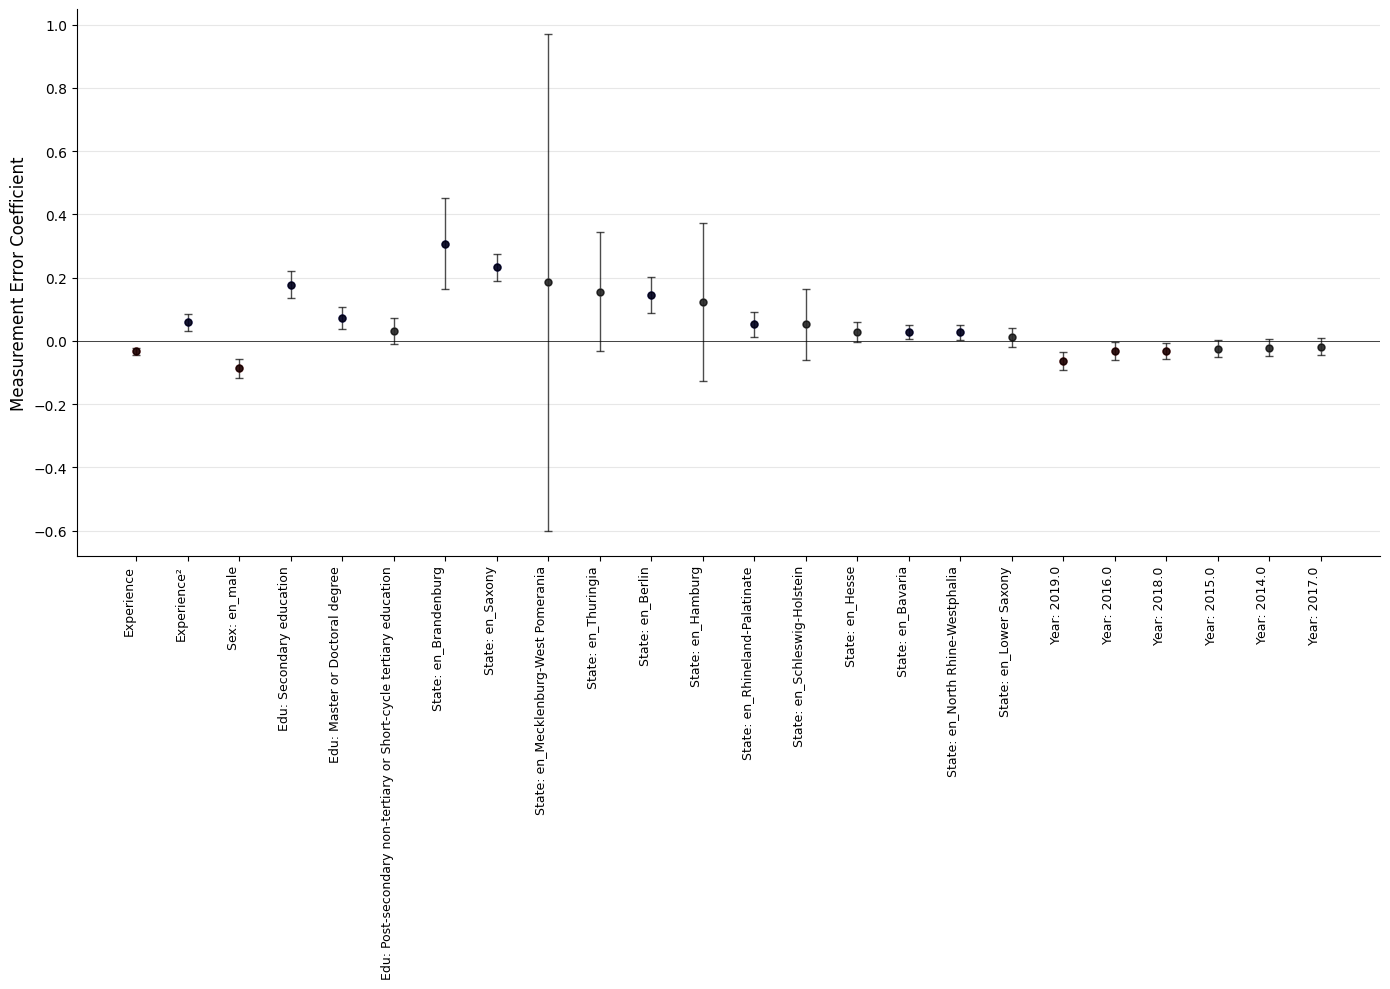

In [192]:
# Visualize measurement error coefficients with confidence intervals

# Extract coefficients for variables of interest
experience_vars = ['pgexpft_mean', 'pgexpft_sq_mean']
sex_vars = [v for v in params_llm.index if v.startswith('sex_')]
education_vars = [v for v in params_llm.index if v.startswith('education_')]
state_vars = [v for v in params_llm.index if v.startswith('state_')]
year_vars = [v for v in params_llm.index if v.startswith('syear_')]

# Sort each category by absolute measurement error coefficient value
sex_vars_sorted = sorted(sex_vars, key=lambda x: abs(params_me[x]), reverse=True)
education_vars_sorted = sorted(education_vars, key=lambda x: abs(params_me[x]), reverse=True)
state_vars_sorted = sorted(state_vars, key=lambda x: abs(params_me[x]), reverse=True)
year_vars_sorted = sorted(year_vars, key=lambda x: abs(params_me[x]), reverse=True)

# Combine all variables (experience stays in original order)
plot_vars = experience_vars + sex_vars_sorted + education_vars_sorted + state_vars_sorted + year_vars_sorted

# Create labels and extract coefficients with standard errors
labels = []
me_coefs = []
me_se = []

for var in plot_vars:
    if var in params_me.index:
        # Clean up variable name for display
        if var.startswith('sex_'):
            label = var.replace('sex_', 'Sex: ')
        elif var.startswith('education_'):
            label = var.replace('education_grouped_', 'Edu: ')
        elif var.startswith('state_'):
            label = var.replace('state_', 'State: ')
        elif var == 'pgexpft_mean':
            label = 'Experience'
        elif var == 'pgexpft_sq_mean':
            label = 'Experience²'
        elif var.startswith('syear_'):
            label = var.replace('syear_', 'Year: ')
        else:
            label = var
        
        labels.append(label)
        me_coefs.append(params_me[var])
        me_se.append(se_me[var])

# Convert to arrays
me_coefs = np.array(me_coefs)
me_se = np.array(me_se)

# Calculate 95% confidence intervals (1.96 * SE)
ci_95 = 1.96 * me_se

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Set up positions
x = np.arange(len(labels))

# Plot coefficients with error bars
# Color points based on whether CI includes zero
colors = ['darkgrey' if (coef - ci < 0 and coef + ci > 0) else ('darkred' if coef < 0 else 'darkblue') 
          for coef, ci in zip(me_coefs, ci_95)]

ax.errorbar(x, me_coefs, yerr=ci_95, fmt='o', color='black', ecolor='black', 
            capsize=3, capthick=1, markersize=5, linewidth=1, alpha=0.7)

# Color the points
for i, (xi, yi, color) in enumerate(zip(x, me_coefs, colors)):
    ax.plot(xi, yi, 'o', color=color, markersize=5, alpha=0.7)

# Customize plot
ax.set_ylabel('Measurement Error Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=9)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

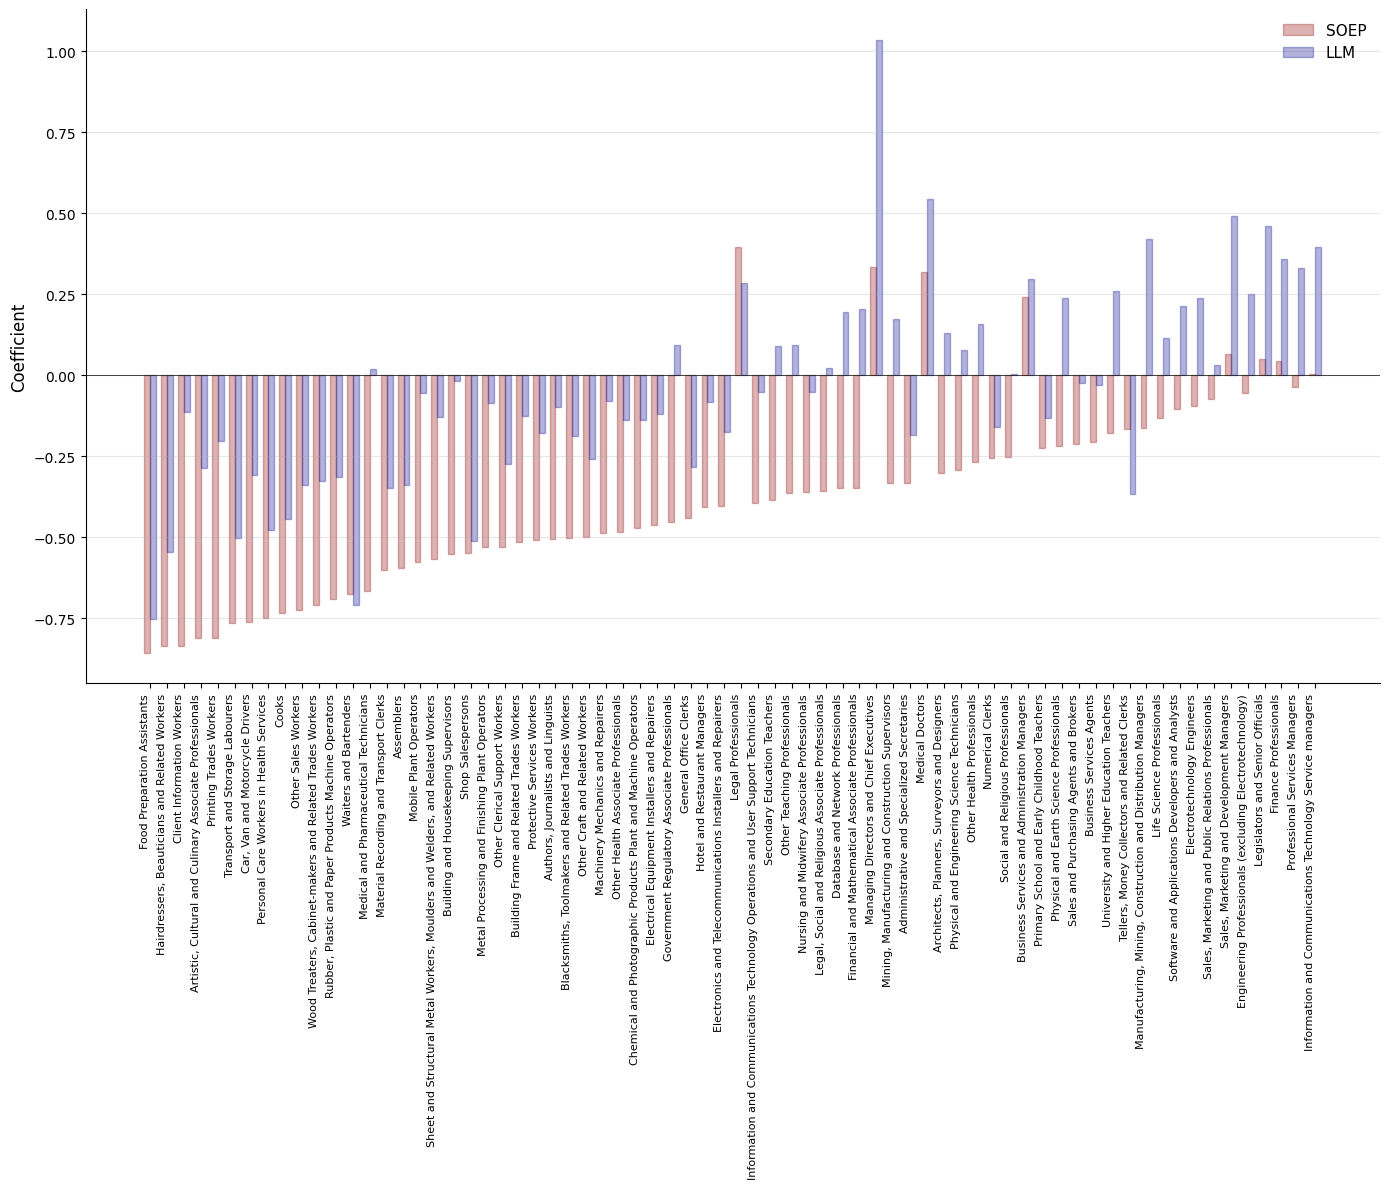

In [193]:
# Visualize coefficient comparison between LLM and SOEP for occupations

# Extract occupation variables
occupation_vars = [v for v in params_llm.index if v.startswith('isco_3_name_')]

# Sort by absolute SOEP coefficient value
occupation_vars_sorted = sorted(occupation_vars, key=lambda x: abs(params_soep[x]), reverse=True)

# Create labels and extract coefficients
labels = []
llm_coefs = []
soep_coefs = []

for var in occupation_vars_sorted:
    if var in params_llm.index and var in params_soep.index:
        # Clean up variable name for display
        label = var.replace('isco_3_name_', '')
        
        labels.append(label)
        llm_coefs.append(params_llm[var])
        soep_coefs.append(params_soep[var])

# Create figure
fig, ax = plt.subplots(figsize=(14, 12))

# Set up bar positions
x = np.arange(len(labels))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, soep_coefs, width, label='SOEP', color='darkred', edgecolor='darkred', alpha=0.3)
bars2 = ax.bar(x + width/2, llm_coefs, width, label='LLM', color='darkblue', edgecolor='darkblue', alpha=0.3)

# Customize plot
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=8)
ax.legend(fontsize=11, frameon=False)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [194]:
valid_df_sorted = valid_df.copy()
valid_df_sorted['abs_measurement_error_log'] = valid_df_sorted['measurement_error_log'].abs()
valid_df_sorted = valid_df_sorted.sort_values('pglabgro_mean', ascending=False)

In [195]:
valid_df.columns

Index(['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en',
       'pglabgro_mean', 'llm_income_mean', 'pgexpft_mean', 'pgexpft_sq_mean',
       'log_pglabgro_mean', 'log_llm_income_mean', 'n_obs',
       'measurement_error', 'measurement_error_log', 'income_quantile'],
      dtype='object')

In [196]:
# Display top rows
valid_df_sorted[valid_df_sorted["pgexpft_mean"] < 5][["measurement_error_log","measurement_error", "llm_income_mean", "pglabgro_mean", "isco_3_name","syear", "education_grouped", "pgexpft_mean"]].head(500)

,measurement_error_log,measurement_error,llm_income_mean,pglabgro_mean,isco_3_name,syear,education_grouped,pgexpft_mean
1163,-0.087750,-286.666667,3433.333333,3720.000000,"Sales, Marketing and Public Relations Professi...",2017.0,Bachelor degree,2.366600
1546,0.059412,169.333333,2883.333333,2714.000000,"Legal, Social and Religious Associate Professi...",2019.0,Post-secondary non-tertiary or Short-cycle ter...,3.633400
1195,0.215275,601.646465,3055.555556,2453.909091,Social and Religious Professionals,2017.0,Bachelor degree,4.530273
1331,-0.067374,-153.845238,2239.583333,2393.428571,Material Recording and Transport Clerks,2018.0,Secondary education,4.999857
1050,0.275509,740.277778,2881.944444,2141.666667,"Legal, Social and Religious Associate Professi...",2017.0,Secondary education,3.902667
946,-0.328997,-523.500000,1354.166667,1877.666667,Waiters and Bartenders,2016.0,Secondary education,4.388833


In [197]:
# Compute mean weighted measurement error by n_obs

# Group by n_obs and calculate weighted mean measurement error
me_by_nobs = valid_df.groupby('n_obs').apply(
    lambda x: np.average(x['measurement_error_log'], weights=x['n_obs'])
).reset_index()
me_by_nobs.columns = ['n_obs', 'mean_me_log']

# Also calculate the total weighted observations for each n_obs group (for reference)
obs_by_nobs = valid_df.groupby('n_obs').size().reset_index(name='count')
obs_by_nobs['total_weighted_obs'] = obs_by_nobs['n_obs'] * obs_by_nobs['count']
obs_by_nobs = obs_by_nobs[['n_obs', 'total_weighted_obs']]

# Merge
me_by_nobs = me_by_nobs.merge(obs_by_nobs, on='n_obs')

# Sort by n_obs
me_by_nobs = me_by_nobs.sort_values('n_obs')

print("Mean Weighted Measurement Error by n_obs:")
print(me_by_nobs.head(20))
print(f"\nTotal groups: {len(me_by_nobs)}")


Mean Weighted Measurement Error by n_obs:
    n_obs  mean_me_log  total_weighted_obs
0       4    -0.250637                   8
1       5    -0.173994                1900
2       6    -0.160159                1842
3       7    -0.211340                1267
4       8    -0.143365                1368
5       9    -0.184673                 972
6      10    -0.169600                 750
7      11    -0.143983                 671
8      12    -0.149780                 648
9      13    -0.133254                 637
10     14    -0.156085                 588
11     15    -0.140256                 495
12     16    -0.166471                 416
13     17    -0.099602                 323
14     18    -0.156612                 450
15     19    -0.156593                 380
16     20    -0.158329                 300
17     21    -0.188258                 504
18     22    -0.244887                 198
19     23    -0.179702                 184

Total groups: 45


/var/folders/5h/mgjr5c410p33q26211w0wr640000gn/T/ipykernel_29007/1041954085.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  me_by_nobs = valid_df.groupby('n_obs').apply(


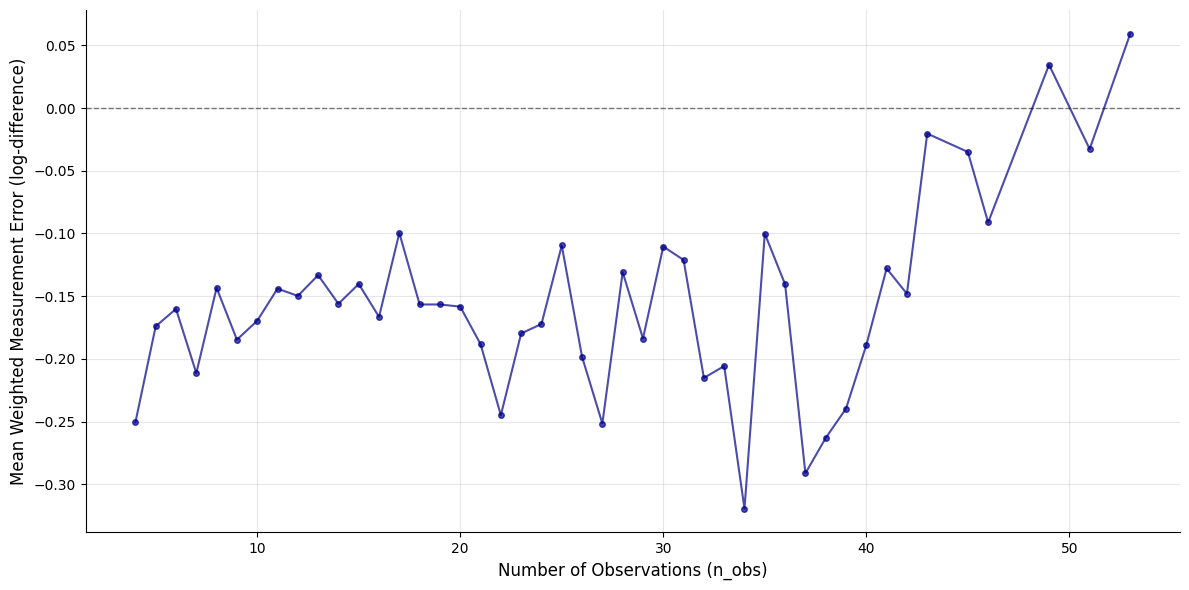

In [198]:
# Visualize mean weighted measurement error by n_obs

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot mean measurement error
ax.plot(me_by_nobs['n_obs'], me_by_nobs['mean_me_log'], 
        color='darkblue', linewidth=1.5, marker='o', markersize=4, alpha=0.7)

# Add horizontal line at zero
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

ax.set_xlabel('Number of Observations (n_obs)', fontsize=12)
ax.set_ylabel('Mean Weighted Measurement Error (log-difference)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


In [199]:
me_by_nobs

,n_obs,mean_me_log,total_weighted_obs
0,4,-0.250637,8
1,5,-0.173994,1900
2,6,-0.160159,1842
3,7,-0.211340,1267
4,8,-0.143365,1368
5,9,-0.184673,972
6,10,-0.169600,750
7,11,-0.143983,671
8,12,-0.149780,648
9,13,-0.133254,637
